#### importing library 

In [2]:
import numpy as nm
import pandas as pd
import matplotlib.pyplot as plt

#### 1.Data Ingestion (or Data Loading)
Reading and importing the raw data into your environment.

In [3]:
zomato=pd.read_csv('Zomato.csv')

#### 2.Data Profiling or Data Inspection 
 Checking the shape, info, structure, and basic properties.

In [4]:
zomato.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
zomato.shape

(148, 7)

In [6]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [7]:
zomato.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [8]:
zomato.index

RangeIndex(start=0, stop=148, step=1)

##### 3.Data Cleaning (or Data Cleansing)
Handling missing values, removing duplicates, and fixing data types.

In [9]:
# Checking missing 
zomato.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

No missing values in Our Data Set 

In [10]:
# Checking duplicate 
zomato.duplicated().sum()

np.int64(0)

There is O duplicate record in our data set

Data type of all columns are right according to value  but we can notice that there is a column rate which is storing object value which shoud store float so we will correct that

##### Data Transformation (or Data Wrangling) – 
Normalising, scaling, filtering, or restructuring the data for analysis.

In [11]:
# lets correct first rate columns 
zomato['rate'].head()

0    4.1/5
1    4.1/5
2    3.8/5
3    3.7/5
4    3.8/5
Name: rate, dtype: object

In [12]:
zomato['rating']=zomato['rate'].str.extract(r"(\d+\.?\d*)")
zomato['rating']=zomato['rating'].astype(float)
print(zomato['rating'].dtype)


float64


In [13]:
# renaming cost of columns  "approx_cost(for two people)" 
zomato['cost']=zomato['approx_cost(for two people)']
zomato['listed_in_type']=zomato['listed_in(type)']

In [14]:
zomato.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),rating,cost,listed_in_type
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet,4.1,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet,4.1,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet,3.8,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet,3.7,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet,3.8,600,Buffet


In [15]:
# delete column like rate, approx_cost(for two people) and listed_in(type) bcz we copy of every columns with respective value, and for inserting it into database so we need clean columns and value 

zomato.drop(columns=['rate','approx_cost(for two people)','listed_in(type)'],inplace=True)

In [16]:
zomato.head()

,name,online_order,book_table,votes,rating,cost,listed_in_type
0,Jalsa,Yes,Yes,775,4.1,800,Buffet
1,Spice Elephant,Yes,No,787,4.1,800,Buffet
2,San Churro Cafe,Yes,No,918,3.8,800,Buffet
3,Addhuri Udupi Bhojana,No,No,88,3.7,300,Buffet
4,Grand Village,No,No,166,3.8,600,Buffet


In [17]:
zomato['rating_level'] = zomato['rating'].apply(
    lambda rating: 'High Rating' if rating >= 4.0 else ('Average Rating' if rating >= 3.0 else 'Low Rating')
)
zomato['rating_level']

0         High Rating
1         High Rating
2      Average Rating
3      Average Rating
4      Average Rating
            ...      
143    Average Rating
144    Average Rating
145       High Rating
146    Average Rating
147    Average Rating
Name: rating_level, Length: 148, dtype: object

In [18]:
zomato['cost_status'] = zomato['cost'].apply(
    lambda rating: 'High Cost' if rating >= 800 else ('Moderate Cost' if rating >= 500 else 'Low Cost')
)
zomato['cost_status']

0          High Cost
1          High Cost
2          High Cost
3           Low Cost
4      Moderate Cost
           ...      
143         Low Cost
144         Low Cost
145         Low Cost
146        High Cost
147         Low Cost
Name: cost_status, Length: 148, dtype: object

In [19]:
zomato['vote_level'] = zomato['votes'].apply(
    lambda rating: 'Highly Voted' if rating >= 800 else ('Moderate Voted' if rating >= 500 else 'Low Voted')
)
zomato['vote_level']

0      Moderate Voted
1      Moderate Voted
2        Highly Voted
3           Low Voted
4           Low Voted
            ...      
143         Low Voted
144         Low Voted
145    Moderate Voted
146         Low Voted
147         Low Voted
Name: vote_level, Length: 148, dtype: object

In [20]:
zomato.head()

,name,online_order,book_table,votes,rating,cost,listed_in_type,rating_level,cost_status,vote_level
0,Jalsa,Yes,Yes,775,4.1,800,Buffet,High Rating,High Cost,Moderate Voted
1,Spice Elephant,Yes,No,787,4.1,800,Buffet,High Rating,High Cost,Moderate Voted
2,San Churro Cafe,Yes,No,918,3.8,800,Buffet,Average Rating,High Cost,Highly Voted
3,Addhuri Udupi Bhojana,No,No,88,3.7,300,Buffet,Average Rating,Low Cost,Low Voted
4,Grand Village,No,No,166,3.8,600,Buffet,Average Rating,Moderate Cost,Low Voted


#### Descriptive Analysis – 
Generating summary statistics (mean, median, min, max) to understand the dataset's attributes.

In [21]:
zomato.describe()

,votes,rating,cost
count,148.000000,148.000000,148.000000
mean,264.810811,3.633108,418.243243
std,653.676951,0.402271,223.085098
min,0.000000,2.600000,100.000000
25%,6.750000,3.300000,200.000000
50%,43.500000,3.700000,400.000000
75%,221.750000,3.900000,600.000000
max,4884.000000,4.600000,950.000000


In [22]:
zomato['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

In [23]:
zomato['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

In [24]:
zomato['listed_in_type'].value_counts()

listed_in_type
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

In [25]:
zomato['rating_level'].value_counts()

rating_level
Average Rating    104
High Rating        34
Low Rating         10
Name: count, dtype: int64

In [26]:
zomato['cost_status'].value_counts()

cost_status
Low Cost         91
Moderate Cost    40
High Cost        17
Name: count, dtype: int64

In [27]:
zomato['vote_level'].value_counts()

vote_level
Low Voted         125
Highly Voted       12
Moderate Voted     11
Name: count, dtype: int64

#### Exploratory Data Analysis (EDA)

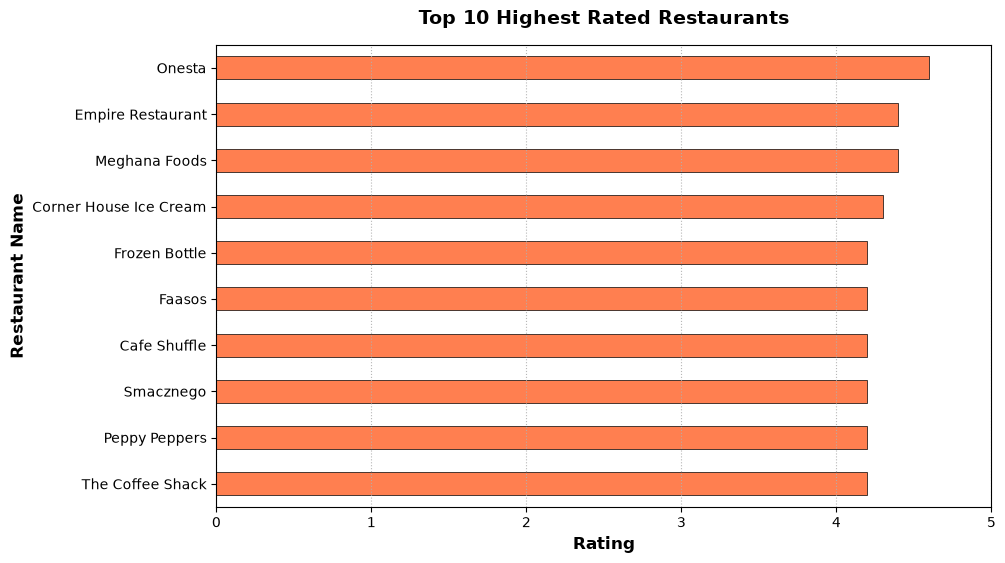

In [28]:
# find Highest Rated Restourant Name  
zomato.groupby('name')['rating'].max().sort_values(ascending=False).head(10).plot(
    kind='barh', 
    figsize=(10, 6),               # Makes the chart larger and easier to read
    color='coral',                 # A warm, appealing color for food/restaurants
    edgecolor='black',             # Adds a clean border around the bars
    linewidth=0.5,
    xlim=(0, 5)                    # Sets the rating scale nicely from 0 to 5
)

# Adding styling titles and labels
plt.title("Top 10 Highest Rated Restaurants", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rating', fontsize=12, fontweight='bold')
plt.ylabel('Restaurant Name', fontsize=12, fontweight='bold')

# Adding a subtle background grid for easy reading
plt.grid(axis='x', linestyle='dotted', alpha=0.9)

# Puts the #1 highest-rated restaurant at the very top of the chart
plt.gca().invert_yaxis()

plt.show()

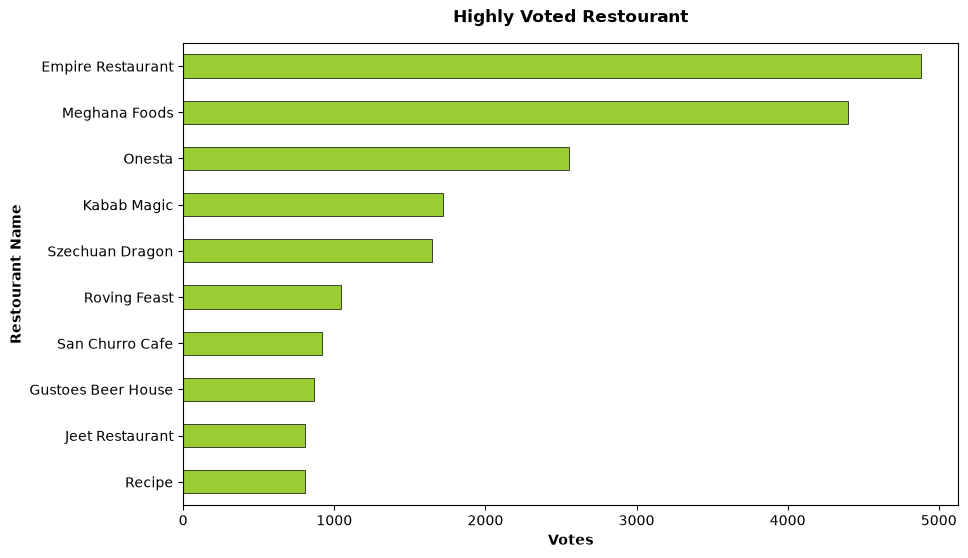

In [29]:
# Highly Voted Restourant 
zomato.groupby('name')['votes'].max().sort_values(ascending=False).head(10).plot(kind='barh'
,figsize=(10,6),
color='yellowgreen',
edgecolor='black',
linewidth=0.5
)
plt.title("Highly Voted Restourant", fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Votes', fontsize=10, fontweight='bold')
plt.ylabel('Restourant Name', fontsize=10,fontweight='bold')

plt.gca().invert_yaxis()
plt.show()

In [30]:
zomato.head()

,name,online_order,book_table,votes,rating,cost,listed_in_type,rating_level,cost_status,vote_level
0,Jalsa,Yes,Yes,775,4.1,800,Buffet,High Rating,High Cost,Moderate Voted
1,Spice Elephant,Yes,No,787,4.1,800,Buffet,High Rating,High Cost,Moderate Voted
2,San Churro Cafe,Yes,No,918,3.8,800,Buffet,Average Rating,High Cost,Highly Voted
3,Addhuri Udupi Bhojana,No,No,88,3.7,300,Buffet,Average Rating,Low Cost,Low Voted
4,Grand Village,No,No,166,3.8,600,Buffet,Average Rating,Moderate Cost,Low Voted


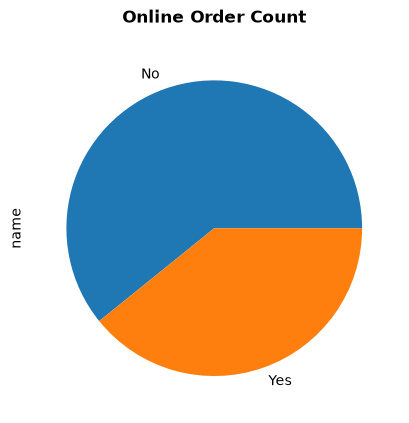

In [40]:
zo=zomato.groupby('online_order')['name'].count().plot(kind='pie')
plt.title("Online Order Count", fontsize=12, fontweight='bold', pad=15)
plt.show()

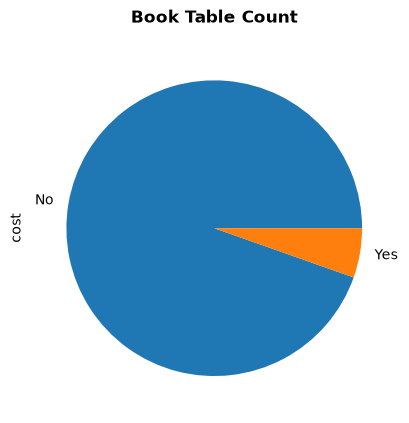

In [41]:
zo=zomato.groupby('book_table')['cost'].count().plot(kind='pie')
plt.title("Book Table Count", fontsize=12, fontweight='bold', pad=15)
plt.show()

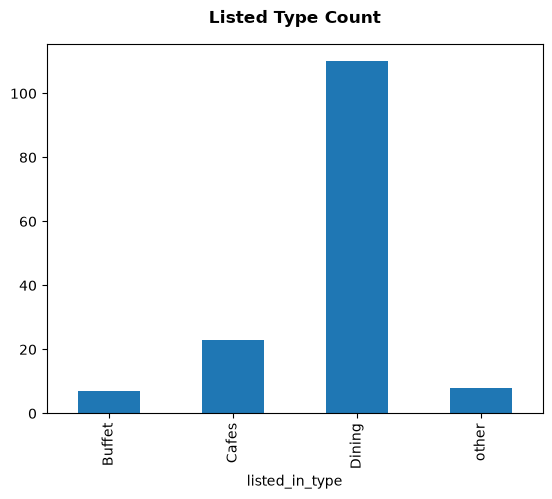

In [43]:
zo=zomato.groupby('listed_in_type')['name'].count().plot(kind='bar')
plt.title("Listed Type Count", fontsize=12, fontweight='bold', pad=15)
plt.show()

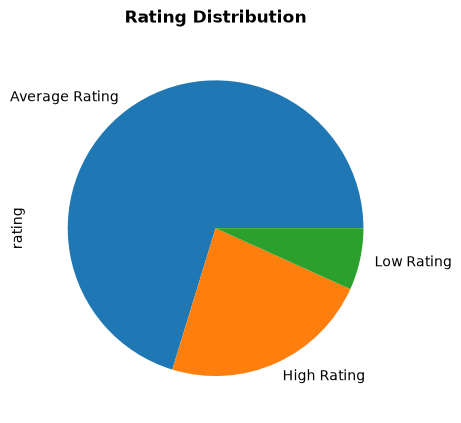

In [44]:
zo=zomato.groupby('rating_level')['rating'].count().plot(kind='pie')
plt.title("Rating Distribution", fontsize=12, fontweight='bold', pad=15)
plt.show()

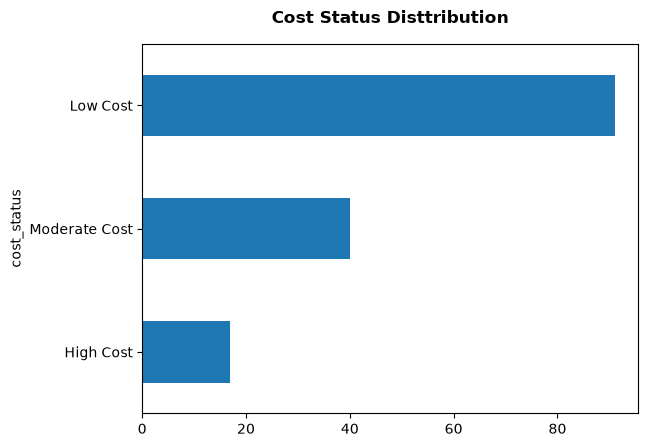

In [46]:
zo=zomato.groupby('cost_status')['name'].count().sort_values(ascending=False).plot(kind='barh')
plt.title("Cost Status Disttribution", fontsize=12, fontweight='bold', pad=15)
plt.gca().invert_yaxis()

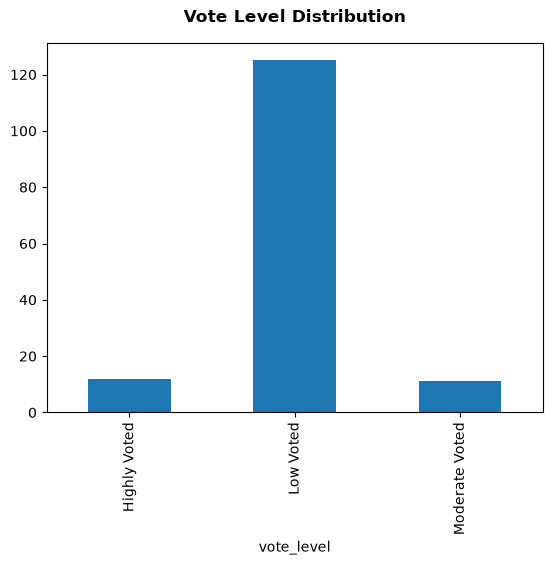

In [48]:
zo=zomato.groupby('vote_level')['name'].count().plot(kind='bar')
plt.title("Vote Level Distribution", fontsize=12, fontweight='bold', pad=15)
plt.show()

In [37]:
# exproting this update csv file for SQL Ananlysis by importing in oracle database and then from Database we will connect power bi then we will make dashboard
zomato.to_csv('updated_Zomato_data.csv', index=False)